# 06 — Applications and Next Steps

Notebooks 01–05 cover `karpathy.py` lines 1–279 in full. This one quotes no new
source. It uses the finished model instead: trained on real language, prompted,
run in parallel, measured, and extrapolated to the size of a model you have
actually heard of.

Five sections, in order:

1. **§6.1** the model trained on natural language rather than names
2. **§6.2** prompting — starting generation from tokens instead of `BOS`
3. **§6.3** why attention parallelises and recurrence does not
4. **§6.4** every matrix and vector in the model, with its dimensions
5. **§6.5** the same architecture at GPT-2 and GPT-3 scale

Unlike 01–05, **every cell here runs**. There are no dedented source fragments, so
"Run All" is clean rather than raising at the first quoted cell.

§6.1 and §6.2 train on the Beatles corpus, which is copyrighted and not committed —
see `data_attributions.md`. Regenerate it locally with `python get_lcgpt_corpus.py`
before running. **The outputs of those two sections are cleared in the committed
notebook**, because a 22,912-parameter model trained on 1,077 lines reproduces some
of them verbatim; §6.2 demonstrates exactly that. Run the cells to see your own.

## 6.1 A model trained on real language

Every model so far has been trained on `data/names.txt` — single words, one per
document, 27 letter-level tokens. This trains the same code on lyrics with
`token_type='word'`, which the CLI has supported for some time but which no
notebook has used.

Three things change and nothing else does:

- **vocabulary** 27 → 612, because tokens are now words
- **parameters** 4,192 → 22,912, all of it in `wte` and `lm_head`
- **truncation inverts** — as letters, 89% of these lines overflow `block_size`;
  as words, one line does

The architecture is untouched: still one layer, `n_embd=16`, four heads.

In [ ]:
import sys; sys.path.insert(0, '..')   # karpathy.py and lcgpt.py live one level up
import copy, time
import karpathy
import lcgpt

docs = lcgpt.load_docs_textfile('../data/beatles_first3.txt', shuffle=False, verbose=False)
print(f"{len(docs)} documents\n")

config = karpathy.new_model_config(docs, token_type='word', seed=42)

Training is slower than the names model — 22,912 parameters instead of 4,192, and a
612-way softmax at every position — so this is 200 steps rather than the usual
1,000. That takes a couple of minutes.

In [ ]:
t0 = time.time()
karpathy.train(config, docs, num_steps=200, verbose=False)
print(f"200 steps in {time.time() - t0:.0f}s")

config_200 = copy.deepcopy(config)    # kept for §6.2; parameters are graph leaves, so this is cheap

for T in (1.0, 0.7):
    print(f"\n--- temperature {T} ---")
    karpathy.generate(config, num_samples=6, temperature=T, seed=7)

### More training makes it worse

The obvious next move is more steps. It does not work: by 400 the model collapses
onto short, high-frequency lines — `and i`, `i do` — because the corpus is full of
them and BOS is the easy prediction.

This is worth seeing directly, because the loss curve does not show it. Loss keeps
falling while the samples get less interesting. At this size the model has enough
capacity to memorise the length distribution and not enough to do anything else
with the extra steps.

In [ ]:
karpathy.train(config, docs, num_steps=200, verbose=False)   # 200 -> 400
print("--- 400 steps ---")
karpathy.generate(config, num_samples=6, seed=7)

## 6.2 Prompting

Not from the source.

`generate` starts every sample the same way (line 263):

```python
token_id = BOS
```

Prompting is changing that one line into a loop. Run the model over the prompt
tokens first and **throw the logits away** — the point of those calls is their side
effect. `gpt` appends to `keys[li]` and `values[li]` on every call (lines 123–124),
so running the prompt through leaves the KV cache holding exactly what it would
hold if the model had generated that prefix itself. Sampling then continues from
the last prompt token.

That is the whole mechanism. In production this is called *prefill*, and it is the
half of inference that parallelises — see §6.3.

In [ ]:
import random
from karpathy import softmax, doc_to_tokens, gpt, tokens_to_text

def generate_prompted(config, prompt, num_samples=4, temperature=1.0, seed=0, logit_model=gpt):
    """`generate`, but seeded with `prompt` instead of starting from BOS alone."""
    random.seed(seed)
    n_layer, block_size = config['n_layer'], config['block_size']
    vocab_size, uchars, BOS = config['vocab_size'], config['uchars'], config['BOS']
    token_type = config['token_type']

    ids = [BOS] + [uchars.index(t) for t in doc_to_tokens(prompt, token_type)]
    samples = []
    for _ in range(num_samples):
        keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]

        # prefill: run the prompt through, keeping only the side effect on keys/values
        token_id, pos_id = ids[0], 0
        for next_id in ids[1:]:
            logit_model(config, token_id, pos_id, keys, values)
            token_id, pos_id = next_id, pos_id + 1

        # decode: identical to the loop in `generate`, but starting from where the prompt left off
        out = []
        while pos_id < block_size:
            logits = logit_model(config, token_id, pos_id, keys, values)
            probs = softmax([l / temperature for l in logits])
            token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
            if token_id == BOS:
                break
            out.append(uchars[token_id])
            pos_id += 1
        samples.append(tokens_to_text(out, token_type))
    return samples

The prefill path has to be a strict generalisation of `generate`: with an empty
prompt it is the same computation, so at the same seed it must produce the same
samples.

In [ ]:
mine = generate_prompted(config_200, "", num_samples=4, seed=7)
theirs = karpathy.generate(config_200, num_samples=4, seed=7, verbose=False)
print("empty prompt reproduces generate():", mine == theirs)

Now with actual prompts. Watch the third one.

In [ ]:
for prompt in ("i", "she loves", "it's been a hard"):
    used = len(doc_to_tokens(prompt, config_200['token_type']))
    left = config_200['block_size'] - 1 - used
    print(f"prompt {prompt!r} — {used} tokens used, {left} positions left")
    for s in generate_prompted(config_200, prompt, num_samples=3, seed=11):
        print(f"    {prompt} | {s}")
    print()

`"i"` gives noise: it is the most common token in the corpus and almost anything
follows it. `"it's been a hard"` gives the same continuation every time, because
the model has memorised the line — 22,912 parameters over 1,077 documents is enough
to store some of them outright. That is the honest version of what a small model
"learns", and the reason this section's outputs are not committed.

### Why this is not chat

The mechanism is complete. What is missing is not architecture:

- **Context.** `block_size=16`, and every prompt token spends one. The counts
  printed above are the whole budget. `wpe` has 16 rows and there is no row 17 —
  position 16 is an `IndexError`, not a degradation.
- **Corpus.** The model samples from what it was trained on. Trained on lyrics, it
  writes lyrics. Instruction-following comes from a corpus where the pattern *is*
  prompt-then-response.
- **Turn structure.** `BOS` does double duty as document separator and stop token
  (lines 206, 269). Chat needs markers distinguishing speakers — extra vocabulary
  entries and a corpus that uses them. That is most of what instruction-tuning is,
  structurally: same architecture, same loss, differently formatted data.

## 6.3 Parallelism: why attention beat recurrence

Not from the source.

The claim usually made for transformers is that they parallelise and RNNs do not.
The precise version:

> **Training parallelises over positions. Generation does not.**

In `train`, the whole document is known before the forward pass starts (line 206).
Position $t$'s output depends on the keys and values at positions $\leq t$ — never
on position $t$'s *own* output — so the positions can be computed in any order, or
all at once. That is the causal mask of §5.5, and it is doing more than hiding the
future: it is what makes the whole sequence trainable in one shot.

In `generate`, token $t+1$ is *sampled* from position $t$'s logits (line 267). The
input to the next step does not exist until the current step finishes. No amount of
hardware removes that dependency.

An RNN is serial in **both**, because its hidden state is a recurrence:
$h_t = f(h_{t-1}, x_t)$. The win is at training time — which is where essentially
all of the compute goes.

The cell below restructures one document's forward pass into three phases:

1. embeddings, and the `k`/`v` for every position — each depends only on its own
   token and position
2. attention and MLP for every position — each depends on phase 1's outputs, and
   on no other position's phase 2
3. the output head

Phase 2 is mapped over positions with a `ThreadPoolExecutor`. `Value` is a plain
Python object graph with no global state, so the threads build one shared graph and
`backward()` walks it single-threaded afterwards — the gradients are unaffected,
which the cell checks.

**This is not faster.** The GIL guarantees it, and pure-Python `Value` arithmetic is
the wrong thing to thread anyway. Real implementations parallelise the tensor
operations rather than the position loop. What the cell demonstrates is the
*dependency structure* — that reordering is legal at all.

In [7]:
# Not from the source: lines 107-146 restructured so the per-position work can be mapped.
import sys; sys.path.insert(0, '..')   # karpathy.py lives one level up
from concurrent.futures import ThreadPoolExecutor
import karpathy, lcgpt
from karpathy import rmsnorm, linear, softmax

def forward_sequential(config, ids):
    """Exactly what train() does: one gpt() call per position, in order."""
    n_layer = config['n_layer']
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    return [karpathy.gpt(config, token_id, pos_id, keys, values)
            for pos_id, token_id in enumerate(ids)]

def forward_parallel(config, ids, workers=4):
    """The same computation, with the per-position work mapped over threads."""
    sd, n_layer = config['state_dict'], config['n_layer']
    n_head, head_dim = config['n_head'], config['head_dim']

    # phase 1a: every position's embedding, independently
    xs = [rmsnorm([t + p for t, p in zip(sd['wte'][tok], sd['wpe'][pos])])
          for pos, tok in enumerate(ids)]

    for li in range(n_layer):
        # phase 1b: every position's key and value, independently
        xn = [rmsnorm(x) for x in xs]
        ks = [linear(x, sd[f'layer{li}.attn_wk']) for x in xn]
        vs = [linear(x, sd[f'layer{li}.attn_wv']) for x in xn]

        # phase 2: attention + MLP at each position, depending only on phase 1
        def one_position(pos):
            q = linear(xn[pos], sd[f'layer{li}.attn_wq'])
            x_attn = []
            for h in range(n_head):
                hs = h * head_dim
                logits = [sum(q[hs+j] * ks[t][hs+j] for j in range(head_dim)) / head_dim**0.5
                          for t in range(pos + 1)]           # <- causal: only t <= pos
                w = softmax(logits)
                x_attn.extend([sum(w[t] * vs[t][hs+j] for t in range(pos + 1))
                               for j in range(head_dim)])
            x = [a + b for a, b in zip(linear(x_attn, sd[f'layer{li}.attn_wo']), xs[pos])]
            h1 = [xi.relu() for xi in linear(rmsnorm(x), sd[f'layer{li}.mlp_fc1'])]
            return [a + b for a, b in zip(linear(h1, sd[f'layer{li}.mlp_fc2']), x)]

        with ThreadPoolExecutor(max_workers=workers) as ex:
            xs = list(ex.map(one_position, range(len(ids))))

    # phase 3: the output head, independently per position
    return [linear(x, sd['lm_head']) for x in xs]

Both paths are run on the same trained model, and compared three ways: the logits,
the loss built on top of them, and the gradients that `backward()` produces. If the
reordering were illegal any of the three would diverge.

In [8]:
def loss_and_grads(config, logits_per_pos, targets):
    """Build the same loss train() builds, backward it, and return the gradients."""
    params = [p for mat in config['state_dict'].values() for row in mat for p in row]
    for p in params:
        p.grad = 0.0
    losses = [-softmax(lg)[tgt].log() for lg, tgt in zip(logits_per_pos, targets)]
    loss = (1 / len(losses)) * sum(losses)
    loss.backward()
    return loss.data, [p.grad for p in params]

docs = lcgpt.load_docs_textfile('../data/names.txt', num_docs=200, verbose=False, seed=0)
config = karpathy.new_model_config(docs, verbose=False, seed=42)
karpathy.train(config, docs, num_steps=50, verbose=False)

ids = [config['BOS']] + [config['uchars'].index(c) for c in 'emmalina']
targets = ids[1:] + [config['BOS']]

seq = forward_sequential(config, ids)
par = forward_parallel(config, ids)
loss_s, grads_s = loss_and_grads(config, seq, targets)
loss_p, grads_p = loss_and_grads(config, par, targets)

print(f"positions            : {len(ids)}")
print(f"max |logit diff|     : {max(abs(a.data - b.data) for A, B in zip(seq, par) for a, b in zip(A, B)):.2e}")
print(f"loss, sequential     : {loss_s:.10f}")
print(f"loss, parallel       : {loss_p:.10f}")
print(f"max |gradient diff|  : {max(abs(a - b) for a, b in zip(grads_s, grads_p)):.2e}")

positions            : 9
max |logit diff|     : 0.00e+00
loss, sequential     : 2.8215542340
loss, parallel       : 2.8215542340
max |gradient diff|  : 0.00e+00


Identical logits, identical loss, identical gradients across all 4,192 parameters.
A training step computed with the positions in no particular order is the same
training step.

The generation direction is where this stops. `generate_prompted` above splits
cleanly along the same line: its **prefill** loop could use `forward_parallel`,
because the prompt is known in advance; its **decode** loop could not, because each
token has to be sampled before the next can be embedded. Every production inference
stack makes exactly this split, for exactly this reason.

## 6.4 The linear algebra in one place

Not from the source. Nothing new — a census of what has already been built.

Dimensions below are the defaults from lines 5–9 with `data/names.txt`:
`n_layer=1`, `n_embd=16`, `block_size=16`, `n_head=4`, so `head_dim=4`, and
`vocab_size=27`.

**Generating one token at one position:**

| Object | Shape | Set by | Line |
|---|---|---|---|
| `token_id`, `pos_id` | scalars | — | 263, 265 |
| `wte` | 27 × 16 | vocabulary | 94 |
| `wpe` | 16 × 16 | `block_size` | 94 |
| `tok_emb`, `pos_emb` | 16 | `n_embd` | 111–112 |
| `x` — the residual stream | **16** | `n_embd` | 113 |
| `wq`, `wk`, `wv` | 16 × 16 each | `n_embd` | 96–98 |
| `q`, `k`, `v` | 16 each | `n_embd` | 120–122 |
| `q_h`, `k_h`, `v_h` | 4 each | `head_dim` | 128–130 |
| `keys[li]`, `values[li]` | *t* × 16 | grows with position | 123–124 |
| `attn_logits`, `attn_weights` | *t* + 1 | positions so far | 131–132 |
| `head_out` | 4 | `head_dim` | 133 |
| `x_attn` | 16 | 4 heads × 4 | 134 |
| `wo` | 16 × 16 | `n_embd` | 99 |
| `mlp_fc1` | 64 × 16 | 4 × `n_embd` | 100 |
| hidden activation | 64 | 4 × `n_embd` | 140–141 |
| `mlp_fc2` | 16 × 64 | back to `n_embd` | 101 |
| `lm_head` | 27 × 16 | vocabulary | 94 |
| `logits`, `probs` | 27 | vocabulary | 145, 267 |

Two readings. Everything is 16 except where it deliberately is not: the vocabulary
at both ends, `head_dim` inside a head, and the 4× widening in the MLP. And the only
shape that *grows* is the KV cache — `keys[li]` gains a row per position, which is
the whole cost of a longer context.

**What training adds:**

| Object | Shape | Line |
|---|---|---|
| `tokens` | *n* + 1 token ids | 206 |
| `losses` | *n* scalars | 212, 220 |
| `loss` | scalar | 221 |
| `params` (flattened) | 4,192 | 196 |
| Adam `m`, `v` | 4,192 each | 197–198 |
| one `.grad` per parameter | 4,192 | 224, 235 |

Adam's state is twice the model. Together with the parameters themselves that is
roughly **3× inference memory** before the computation graph is counted — which is
why training a model needs so much more hardware than running one.

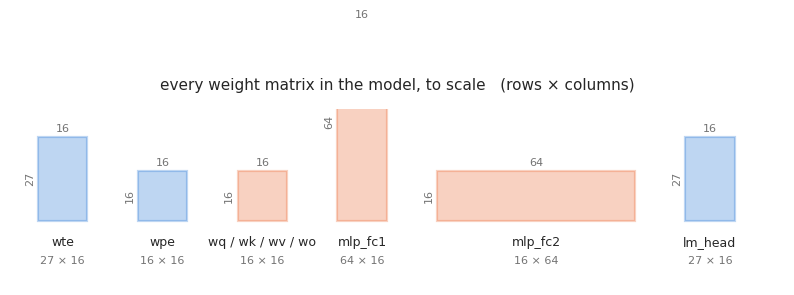

In [9]:
# Not from the source: the weight matrices drawn to scale.
import sys; sys.path.insert(0, '..')   # karpathy.py lives one level up
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import karpathy

C = dict(karpathy.CONFIG_DEFAULTS)
D, B, V = C['n_embd'], C['block_size'], 27
H = 4 * D

BLUE, ORANGE = '#2a78d6', '#eb6834'      # the §2.6 palette: vocabulary-sized vs n_embd-sized
shapes = [('wte',                V, D, BLUE),
          ('wpe',                B, D, BLUE),
          ('wq / wk / wv / wo',  D, D, ORANGE),
          ('mlp_fc1',            H, D, ORANGE),
          ('mlp_fc2',            D, H, ORANGE),
          ('lm_head',            V, D, BLUE)]

fig, ax = plt.subplots(figsize=(10, 3.6))
SCALE, GAP, x = 0.055, 0.9, 0.0
for name, rows, cols, colour in shapes:
    w, h = cols * SCALE, rows * SCALE
    ax.add_patch(Rectangle((x, 0), w, h, facecolor=colour, alpha=0.30, edgecolor=colour, lw=1.6))
    ax.text(x + w / 2, -0.28, name, ha='center', va='top', fontsize=9, color='0.15')
    ax.text(x + w / 2, -0.62, f'{rows} × {cols}', ha='center', va='top', fontsize=8, color='0.45')
    ax.text(x - 0.06, h / 2, str(rows), ha='right', va='center', fontsize=8, color='0.45', rotation=90)
    ax.text(x + w / 2, h + 0.06, str(cols), ha='center', va='bottom', fontsize=8, color='0.45')
    x += w + GAP

ax.set_xlim(-0.5, x); ax.set_ylim(-1.15, V * SCALE + 0.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('every weight matrix in the model, to scale   (rows × columns)',
             color='0.15', fontsize=11, pad=14)
plt.show()

`wpe` is square by coincidence — `block_size` and `n_embd` are unrelated quantities
that both happen to be 16 here. `wte` and `lm_head` are the same shape for a
better reason, and §6.5 is where that matters.

## 6.5 The same architecture, at real scale

Not from the source.

`init_params` is nine lines and fixes every shape in the model. Nothing below
changes it. The claim that this is GPT-2 with the numbers turned down is testable:
put GPT-2's numbers in and see whether the published parameter count falls out.

In [10]:
# Not from the source: the shapes from lines 94-101, counted symbolically.
def count_params(n_layer, n_embd, block_size, vocab_size, tied=False):
    """Parameter count for the architecture in `init_params`, at any scale."""
    wte     = vocab_size * n_embd
    wpe     = block_size * n_embd
    lm_head = 0 if tied else vocab_size * n_embd      # GPT-2 reuses wte as the output head
    attn    = 4 * n_embd * n_embd                     # wq, wk, wv, wo
    mlp     = 2 * 4 * n_embd * n_embd                 # fc1 (4d x d) + fc2 (d x 4d)
    return wte + wpe + lm_head + n_layer * (attn + mlp)

MODELS = [                      # name              layer  embd   ctx   vocab  tied
    ('lcgpt / names',                                   1,    16,    16,     27, False),
    ('lcgpt / Beatles words',                           1,    16,    16,    612, False),
    ('GPT-2 small',                                    12,   768,  1024,  50257, True),
    ('GPT-2 XL',                                       48,  1600,  1024,  50257, True),
    ('GPT-3 175B',                                     96, 12288,  2048,  50257, True),
]

print(f"{'':24s}{'layers':>7}{'n_embd':>8}{'ctx':>7}{'vocab':>8}{'params':>16}{'in layers':>11}")
for name, L, E, B, V, tied in MODELS:
    total = count_params(L, E, B, V, tied)
    layers = L * (4 * E * E + 8 * E * E)
    print(f"{name:24s}{L:>7}{E:>8}{B:>7}{V:>8}{total:>16,}{layers / total:>10.1%}")

# The published figure for GPT-2 small is 124M. If the shapes above are right, it is exact.
assert count_params(12, 768, 1024, 50257, tied=True) == 124_318_464
print("\nGPT-2 small reproduces its published 124M exactly.")

                         layers  n_embd    ctx   vocab          params  in layers
lcgpt / names                 1      16     16      27           4,192     73.3%
lcgpt / Beatles words         1      16     16     612          22,912     13.4%
GPT-2 small                  12     768   1024   50257     124,318,464     68.3%
GPT-2 XL                     48    1600   1024   50257   1,556,609,600     94.7%
GPT-3 175B                   96   12288   2048   50257 174,588,899,328     99.6%

GPT-2 small reproduces its published 124M exactly.


Three things the table earns.

**1. Weight tying is the missing 38M.** Counted the way this code actually builds
the model — `wte` and `lm_head` as separate matrices — GPT-2 small comes to
162.9M, not the 124M everyone quotes. The difference is exactly one
$50257 \times 768$ matrix. GPT-2 ties them: the same weights embed a token on the
way in and score it on the way out, which is defensible because §6.4 showed they
have identical shape, and which saves 31% of the model at that scale. This code
keeps them separate. It is the one architectural simplification in the 279 lines.

**2. Where the parameters live is a ratio, not a size.** The layers cost
$12 \cdot d^2 \cdot L$; the embeddings cost about $2 \cdot V \cdot d$. So the layer
share rises with depth and width and falls with vocabulary — and the two lcgpt rows
sit on opposite sides of it. The names model is **73% layers**, because 27 tokens is
barely a vocabulary at all. Switching to word-level tokens multiplies $V$ by 23 and
changes nothing else, and the same unmodified layer drops to **13%**. Real models
are back on the far side: GPT-3 is 99.6% layers, because 12,288 channels over 96
layers dwarf any vocabulary. Scaling up is scaling $d$ and $L$ — which is why the
`n_embd` column moves by three orders of magnitude and the vocabulary column
barely moves at all.

**3. That flat vocabulary column is tokenization.** 1,077 lines of lyrics gave 612
word-level tokens; word-level English would give millions, and `wte` alone would
dwarf the rest of the model. Byte-pair encoding is what holds the column at ~50k
for any corpus in any language — and it is the one component of a real GPT that
`karpathy.py` does not implement. `doc_to_tokens` (line 149) is `list(doc)` or
`doc.split()`, and everything downstream is indifferent to which.

## Sec 7

### Terms to Call Out
* causal mask
* residual stream
* autodifferentiation
* hub dimension
* ADAM
* logits

### What is actually missing

The forward pass is complete and correct. The gap between this and a production
model, in full:

- **BPE tokenization** — the only structural omission
- **weight tying** — `wte` and `lm_head` as one matrix
- **dropout, and a learned gain on the norm** — `rmsnorm` here has no parameters at
  all (§4.2); GPT-2's layernorm has two per channel
- **batching** — one document per step (line 205); real training does thousands at
  once, which is what makes the parallelism of §6.3 pay
- **tensor operations on a GPU** — the same arithmetic, three or four orders of
  magnitude faster
- Real implementations parallelise the tensor operations rather than the position loop. 
None of those is a different idea. They are the same algorithm, engineered.
- GPT-2 uses layernorm, which also subtracts the mean and applies a learned gain. This drops both

### Where this goes next

Three follow-ups extend past the 279 lines rather than explaining them:

- **Fine-tuning** — starting from trained weights instead of `random.gauss`, and
  what actually happens when you adapt a model to new data
- **Deployment and serving** — the prefill/decode split of §6.3 is where this
  starts, and it is most of what an inference server is
- **Entropy, Markov chains and language** — the companion to notebook 01's n-gram
  counter: Shannon's method, and what the neural network is doing that the counter
  is not